# Import Libraries

In [37]:
import os
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import load_model


from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    roc_curve, 
    confusion_matrix, 
    classification_report
)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## GPU Check

In [38]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


# Load data Files

## Define Paths

In [39]:
base_dir = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

## Data Generator

In [40]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    # medically safe augmentation
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [41]:
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=SEED
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=SEED
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


# Class Imbalance Handling

In [42]:
labels = train_gen.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


# Build Model

## MobileNetV2 (Baseline)

In [43]:
def build_mobilenet():
    base = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    
    base.trainable = False  # initial freezing
    
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs=base.input, outputs=out)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model, base

## ResNet50 (Comparison Model)

In [44]:
def build_resnet():
    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    
    base.trainable = False
    
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs=base.input, outputs=out)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model, base

# Model Training

## Callback

In [45]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3),
]

## Train MobileNetV2

In [46]:
mobilenet_model, mobilenet_base = build_mobilenet()

history_mob = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 759ms/step - accuracy: 0.7009 - loss: 0.5221 - val_accuracy: 0.9147 - val_loss: 0.2403 - learning_rate: 1.0000e-04
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 676ms/step - accuracy: 0.8844 - loss: 0.2394 - val_accuracy: 0.9051 - val_loss: 0.2161 - learning_rate: 1.0000e-04
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 672ms/step - accuracy: 0.9070 - loss: 0.2077 - val_accuracy: 0.9262 - val_loss: 0.1873 - learning_rate: 1.0000e-04
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 670ms/step - accuracy: 0.9303 - loss: 0.1613 - val_accuracy: 0.9262 - val_loss: 0.1770 - learning_rate: 1.0000e-04
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 87s 666ms/step - accuracy: 0.9435 - loss: 0.1370 - val_accuracy: 0.9348 - val_loss: 0.1680 - learning_rate: 1.0000e-04
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 87s 663ms/step - accuracy: 0.9306 - loss: 0.1712 - val_accuracy: 0.9243 - val_loss: 0.1610 - learning_rate: 1.0000e-04
Epoch 7/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 6

In [47]:
resnet_model, resnet_base = build_resnet()

history_resnet = resnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 739ms/step - accuracy: 0.7564 - loss: 0.5105 - val_accuracy: 0.2570 - val_loss: 0.8377 - learning_rate: 1.0000e-04
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 676ms/step - accuracy: 0.8393 - loss: 0.3501 - val_accuracy: 0.6357 - val_loss: 0.6370 - learning_rate: 1.0000e-04
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 680ms/step - accuracy: 0.8645 - loss: 0.3073 - val_accuracy: 0.8399 - val_loss: 0.4383 - learning_rate: 1.0000e-04
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 675ms/step - accuracy: 0.8808 - loss: 0.2710 - val_accuracy: 0.8648 - val_loss: 0.3381 - learning_rate: 1.0000e-04
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 677ms/step - accuracy: 0.8898 - loss: 0.2545 - val_accuracy: 0.8754 - val_loss: 0.2771 - learning_rate: 1.0000e-04
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 680ms/step - accuracy: 0.8886 - loss: 0.2448 - val_accuracy: 0.8523 - val_loss: 0.3345 - learning_rate: 1.0000e-04
Epoch 7/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 6

# Model Evaluation

## Predictions

In [55]:
y_true = test_gen.classes

# MobileNet
y_pred_prob_mob = mobilenet_model.predict(test_gen)
y_pred_mob = (y_pred_prob_mob > 0.5).astype(int)

# ResNet
y_pred_prob_res = resnet_model.predict(test_gen)
y_pred_res = (y_pred_prob_res > 0.5).astype(int)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 432ms/step


## Full Metrics Table

In [103]:
def evaluate(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

mob_metrics = evaluate(y_true, y_pred_mob, y_pred_prob_mob)
res_metrics = evaluate(y_true, y_pred_res, y_pred_prob_res)

df_results = df_results.round(3)
df_results.columns = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

df_results

,Accuracy,Precision,Recall,F1-score,ROC-AUC
MobileNetV2,0.901,0.904,0.941,0.922,0.966
ResNet50,0.881,0.882,0.936,0.908,0.947


# Confusion Matrix

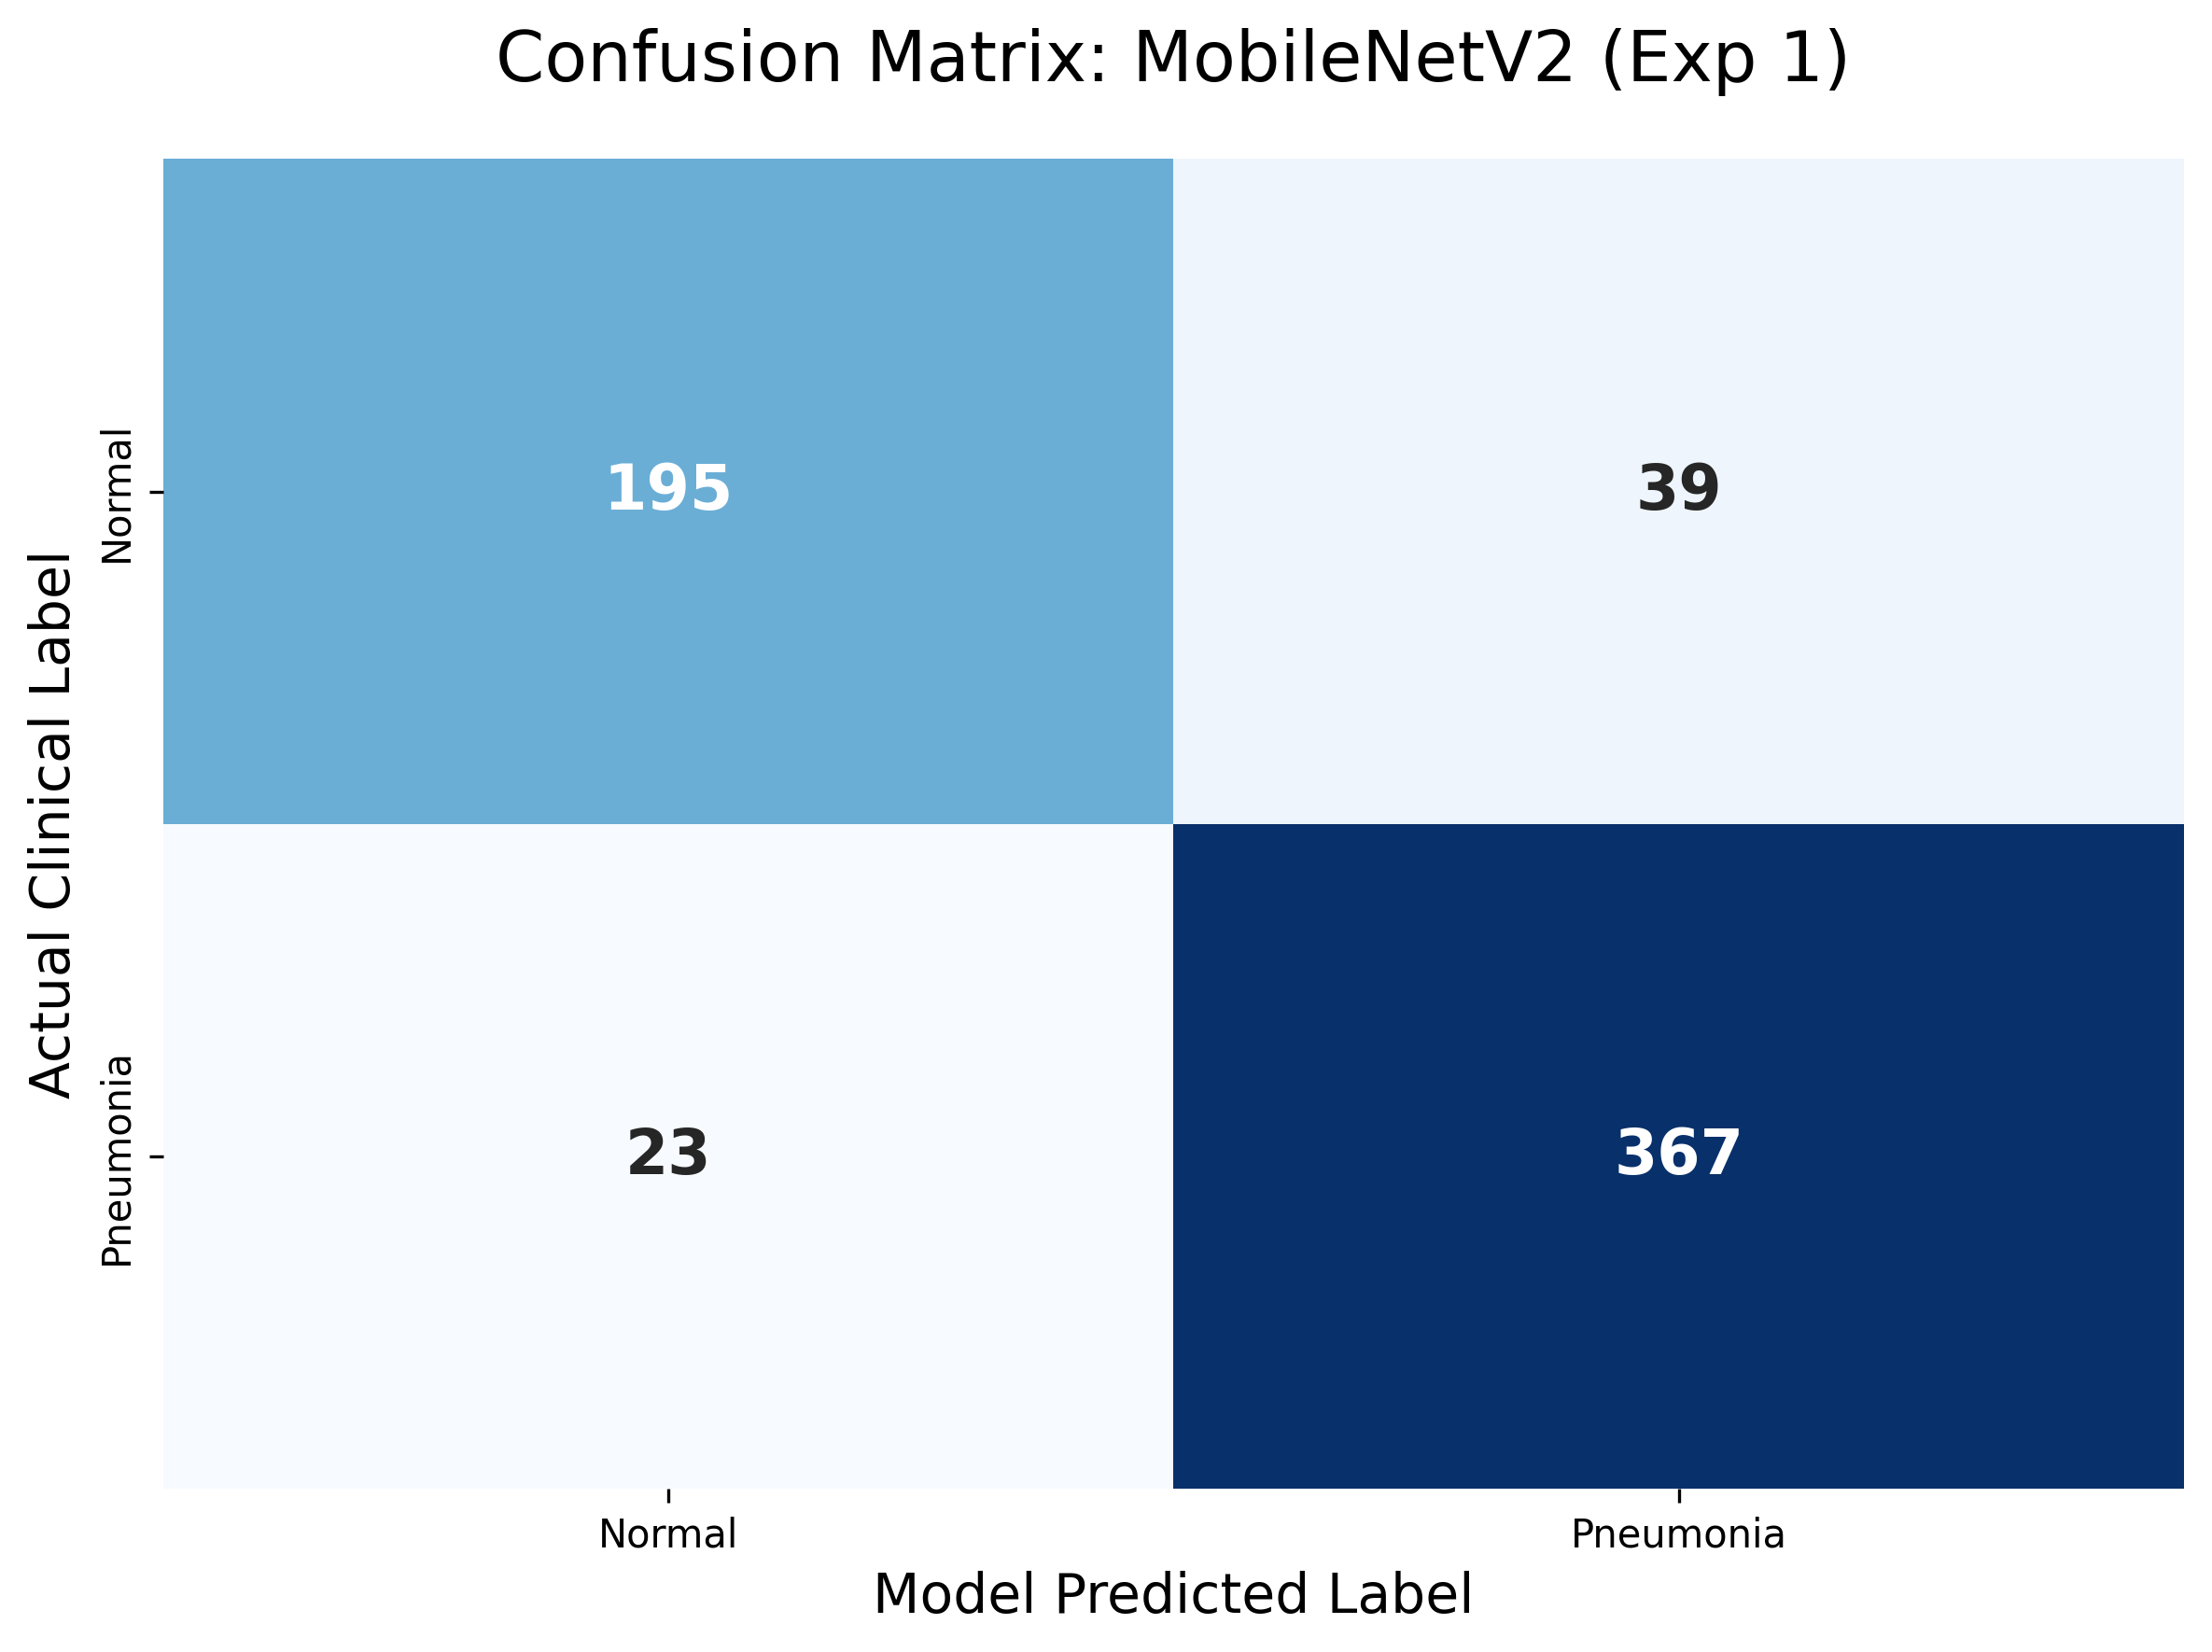

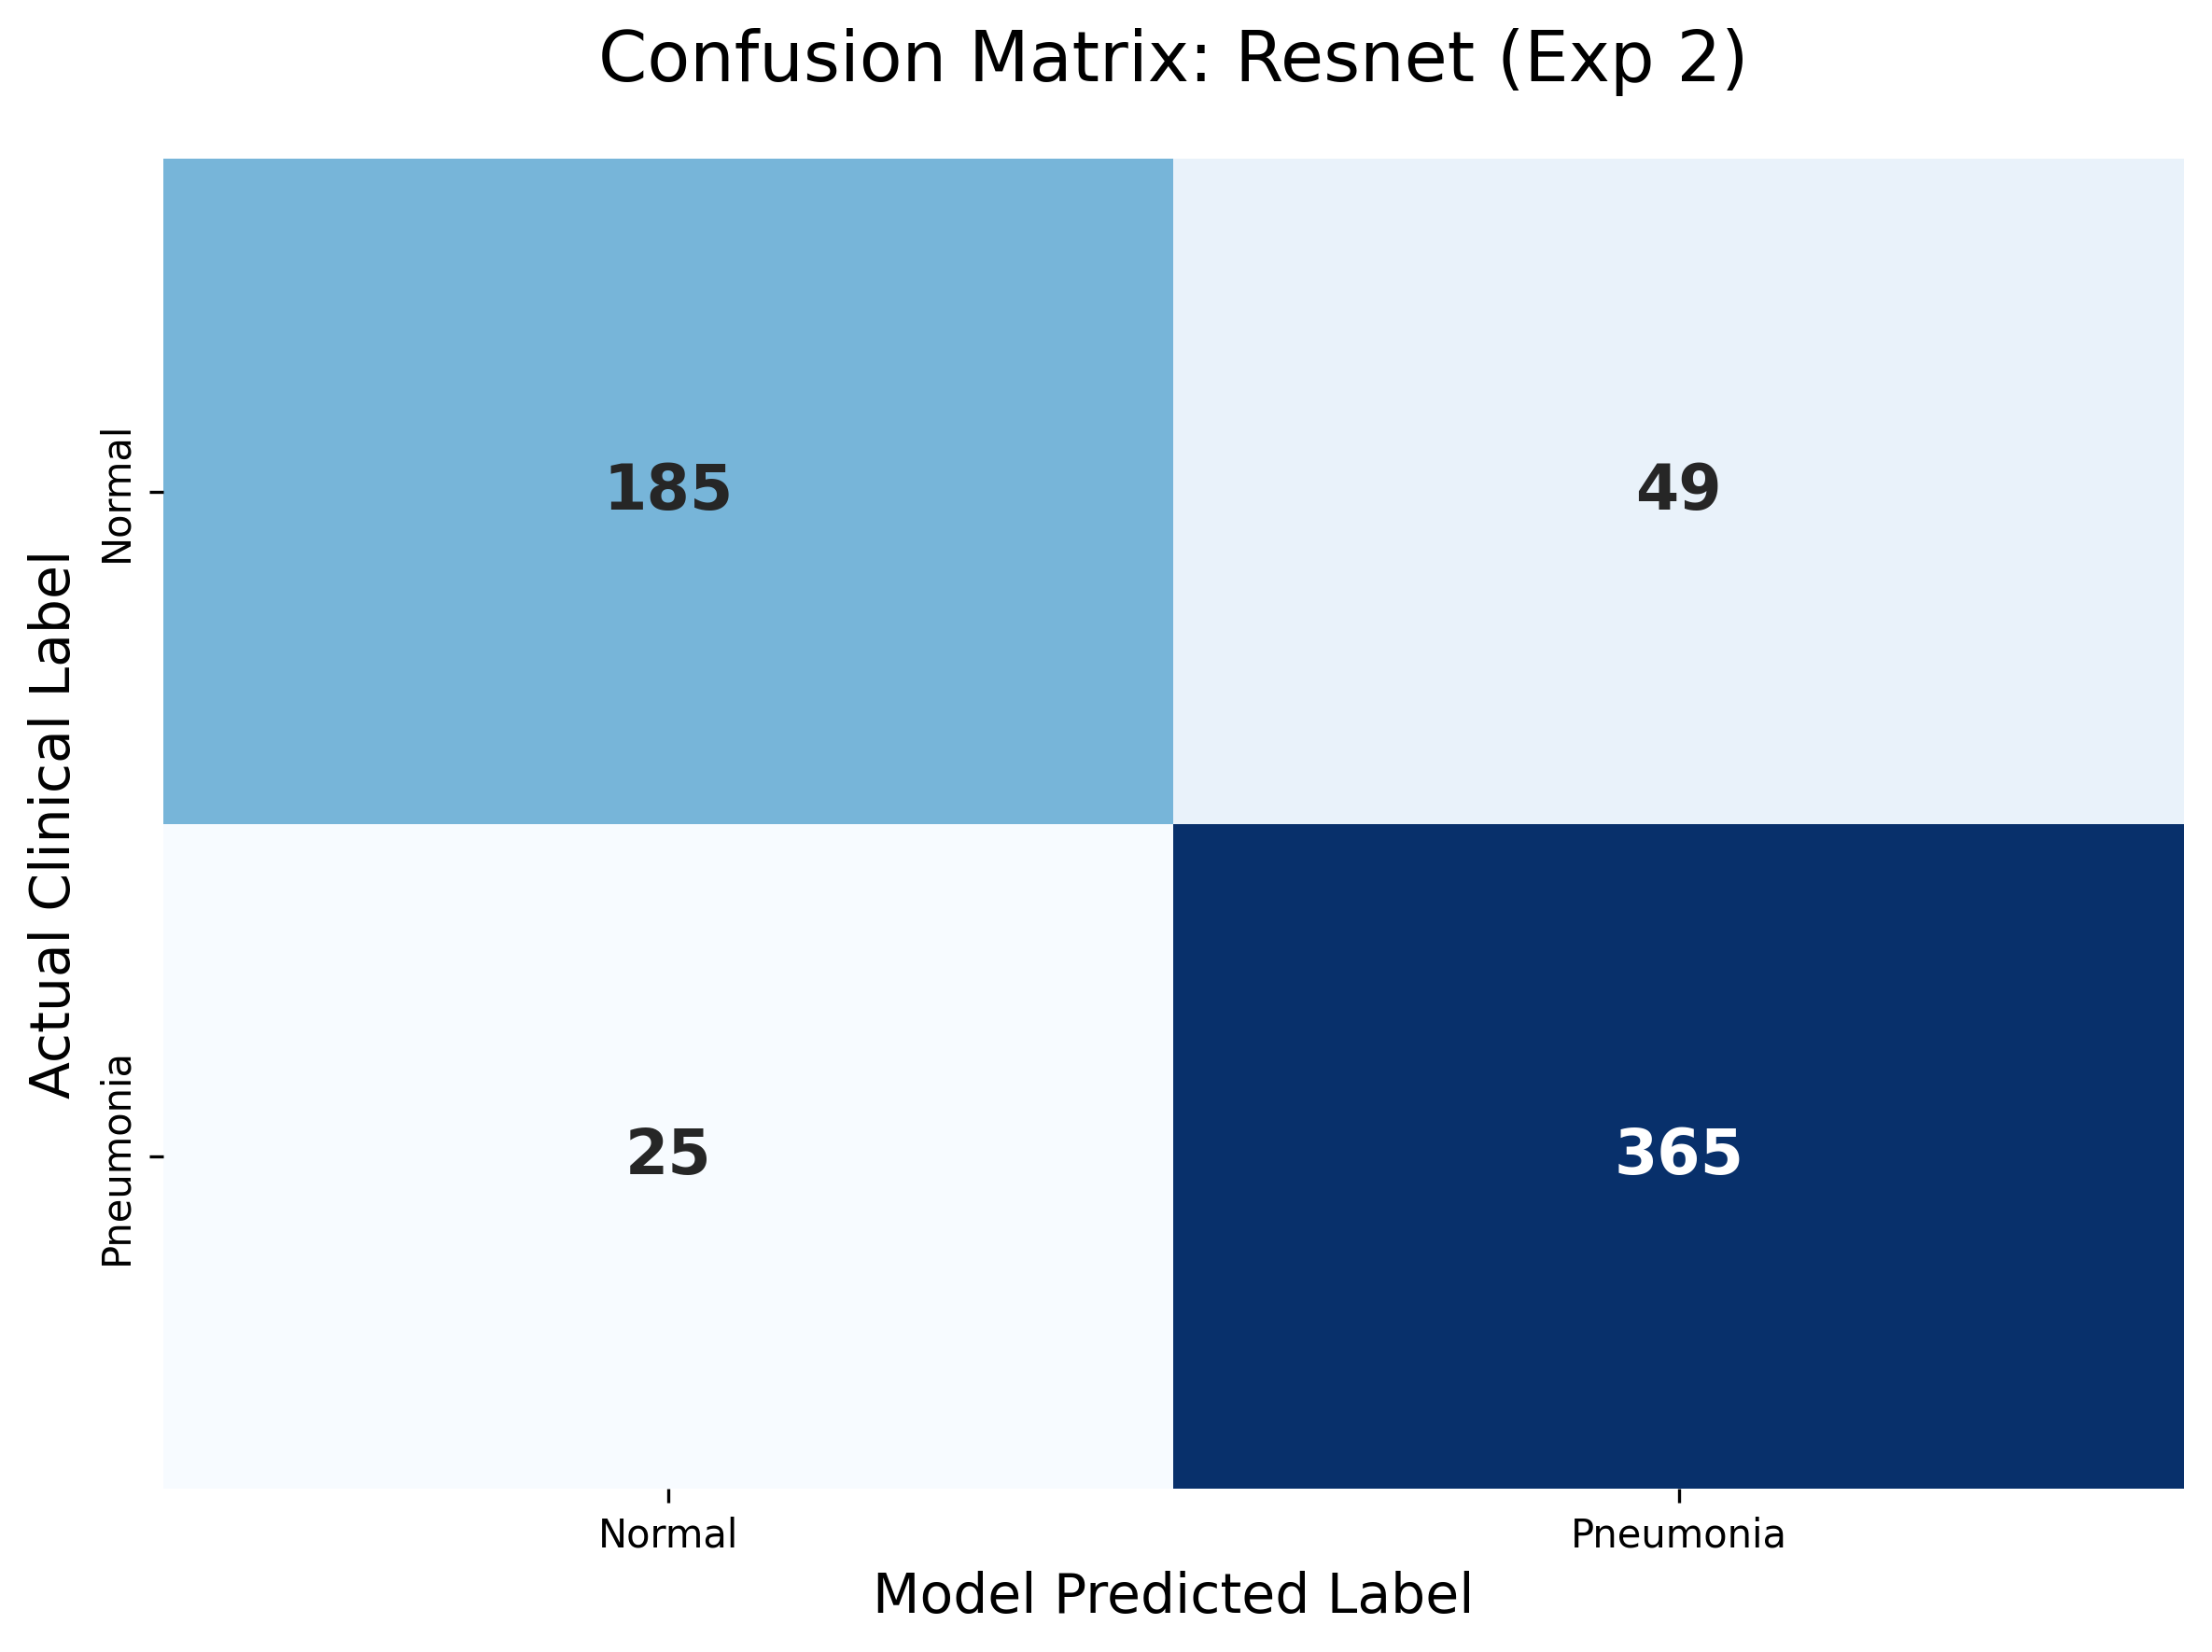

In [91]:
def plot_styled_confusion_matrix(y_true, y_pred, model_name="MobileNetV2"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6), dpi=300)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Normal', 'Pneumonia'], 
                yticklabels=['Normal', 'Pneumonia'],
                annot_kws={"size": 16, "weight": "bold"})
    
    plt.title(f'Confusion Matrix: {model_name}', fontsize=18, pad=20)
    plt.ylabel('Actual Clinical Label', fontsize=14)
    plt.xlabel('Model Predicted Label', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{model_name}_cm.png', bbox_inches='tight')
    plt.show()

# Usage after model.predict():
plot_styled_confusion_matrix(test_gen.classes, y_pred_mob, "MobileNetV2 (Exp 1)")
plot_styled_confusion_matrix(test_gen.classes, y_pred_res, "Resnet (Exp 2)")

# ROC Curve

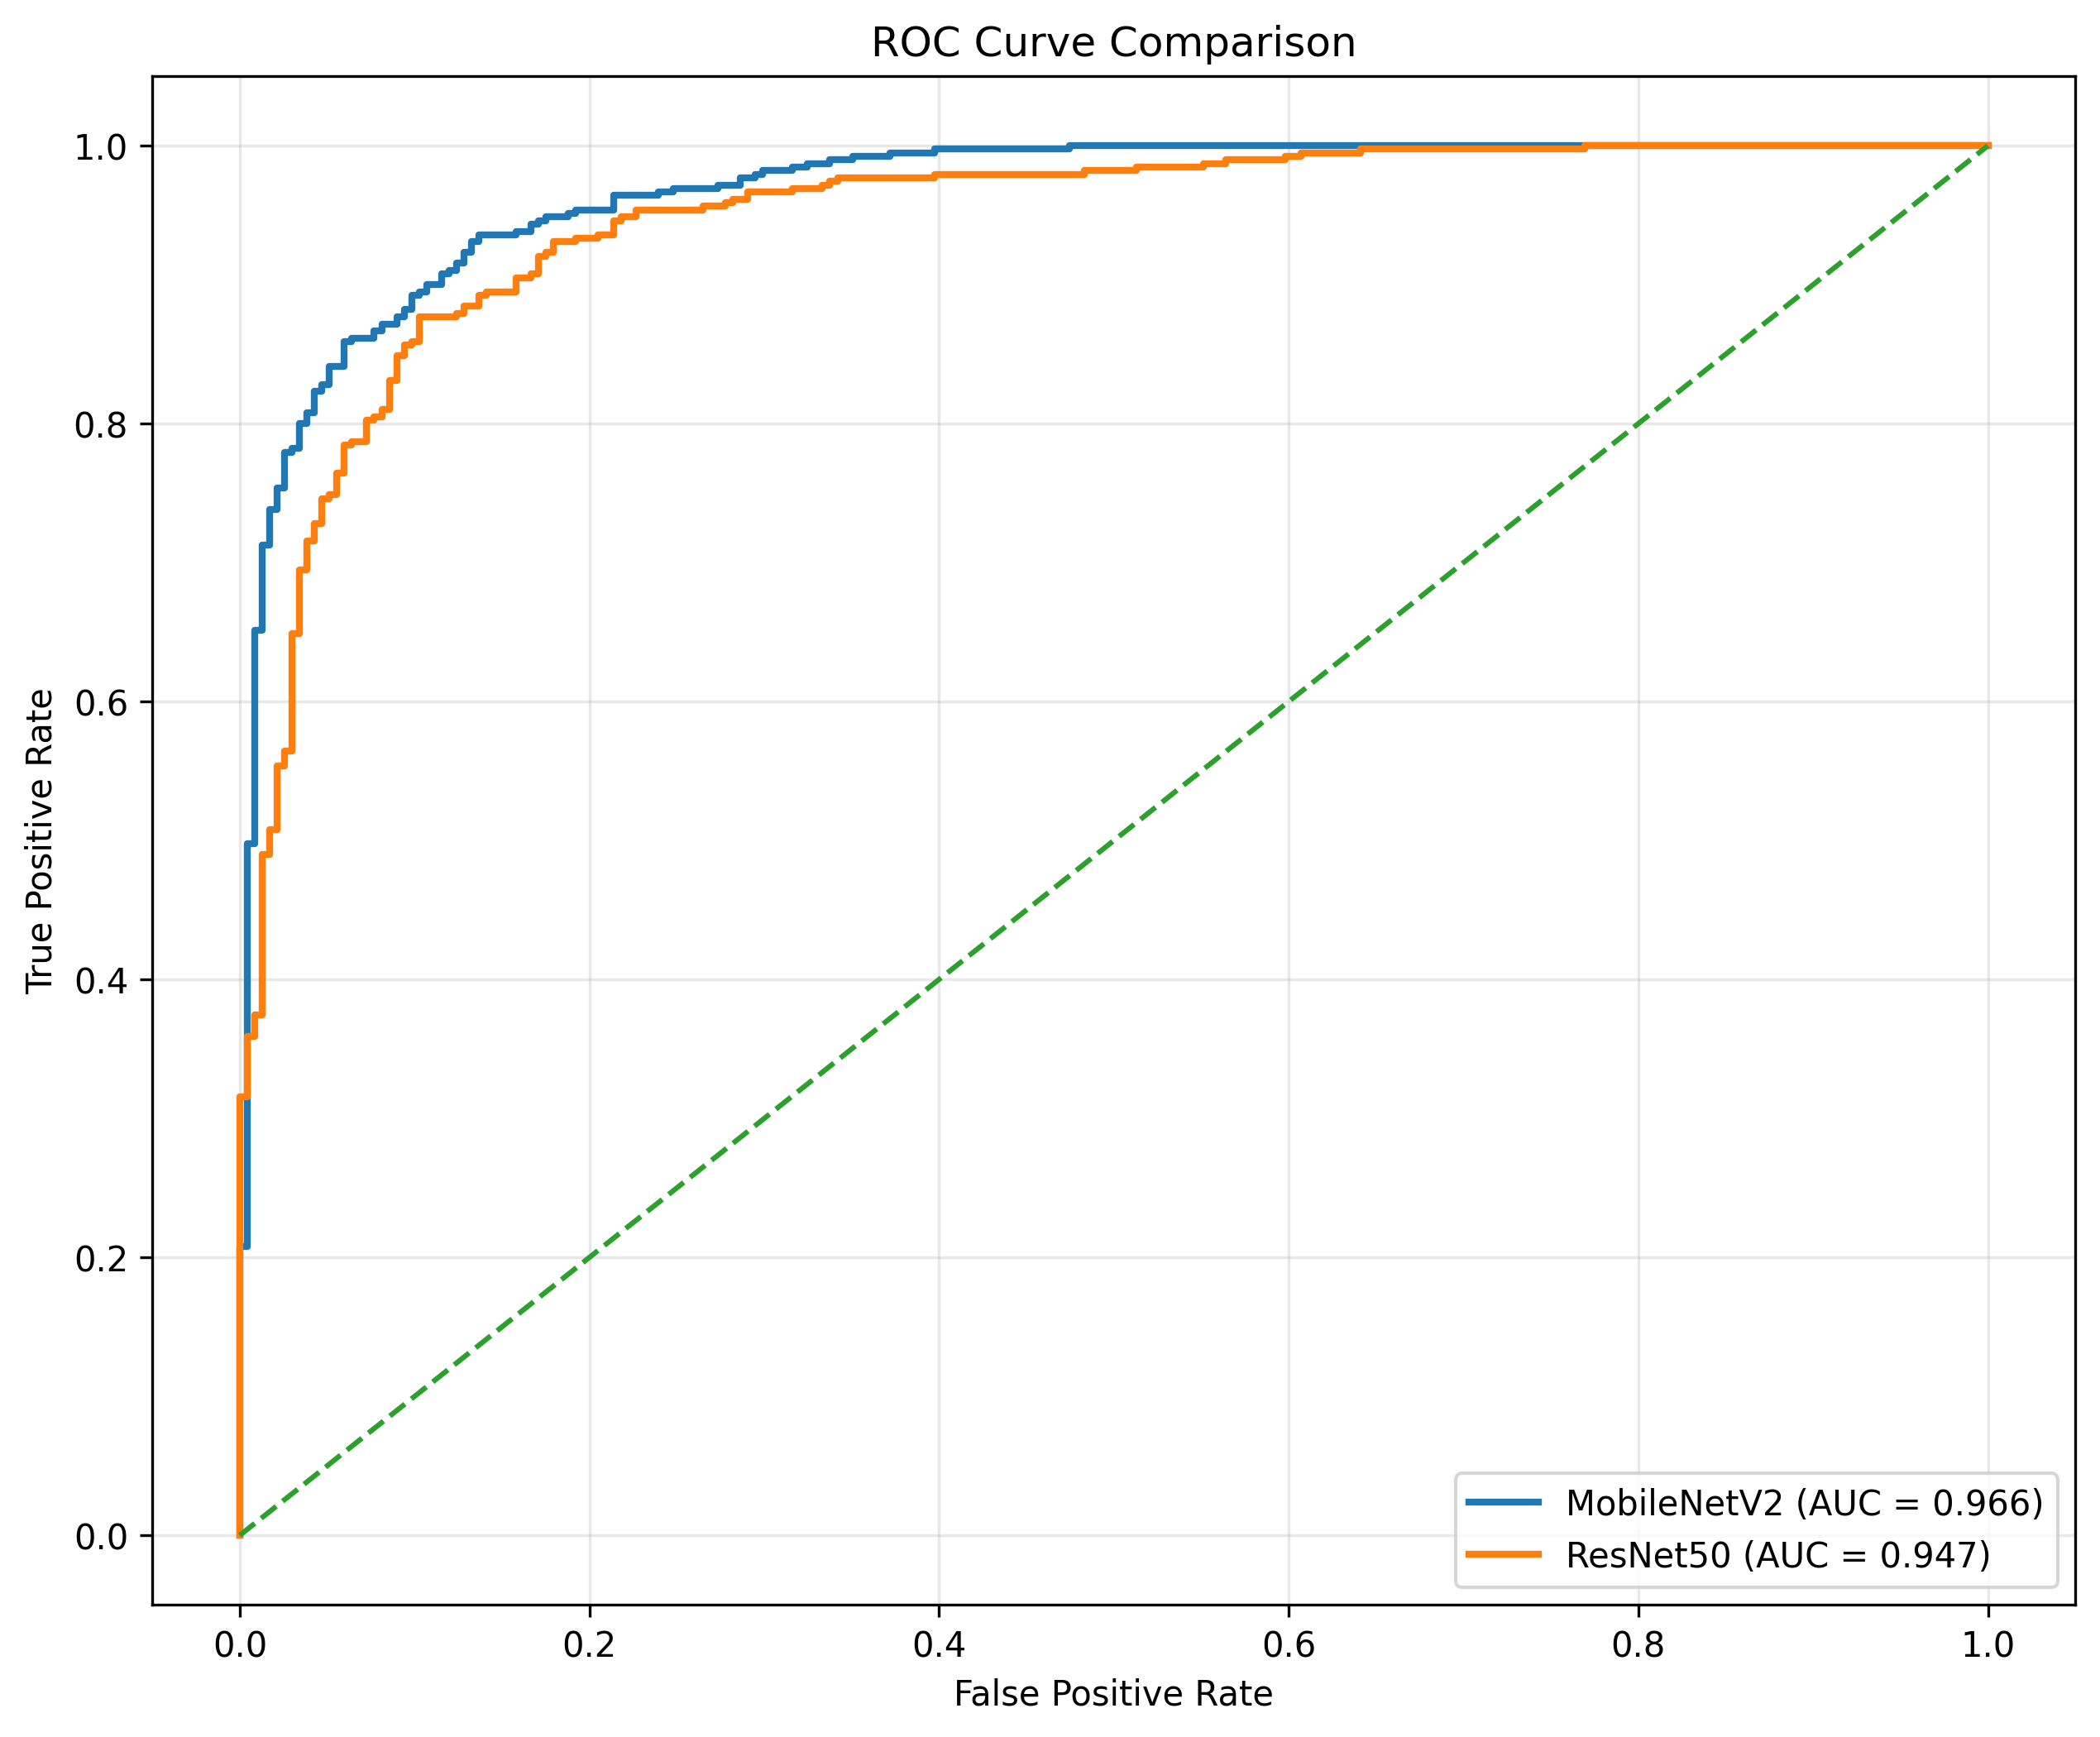

In [94]:
def plot_comparative_roc(results_dict):
    plt.figure(figsize=(10, 8), dpi=300)

    for label, (y_true, y_probs) in results_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_probs)
        auc_score = roc_auc_score(y_true, y_probs)
        plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {auc_score:.3f})')

    # Random classifier baseline
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

results = {
    "MobileNetV2": (y_true, y_pred_prob_mob),
    "ResNet50": (y_true, y_pred_prob_res),
}

plot_comparative_roc(results)

# Training Curve

In [61]:
history_res = history_resnet

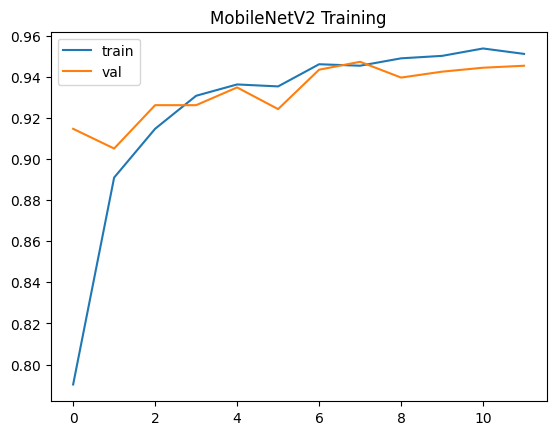

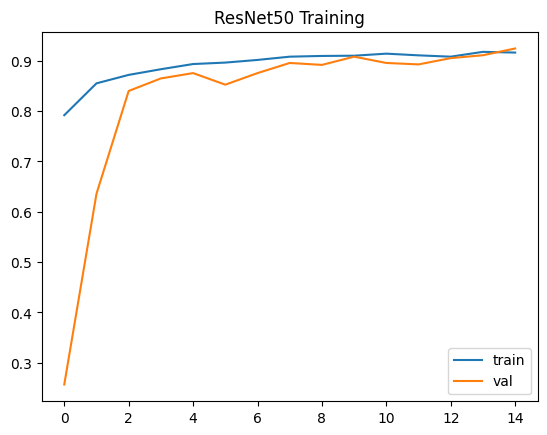

In [62]:
def plot_history(history, title):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title)
    plt.legend(['train', 'val'])
    plt.show()

plot_history(history_mob, "MobileNetV2 Training")
plot_history(history_res, "ResNet50 Training")

# Error Calculate

In [64]:
fp_mob = np.where((y_pred_mob == 1) & (y_true == 0))[0]
fn_mob = np.where((y_pred_mob == 0) & (y_true == 1))[0]

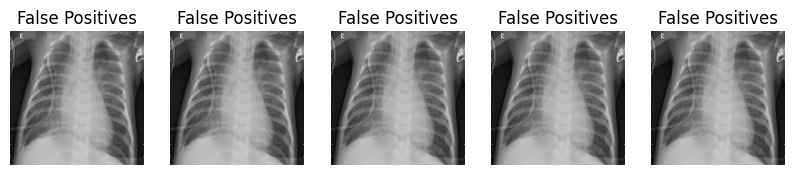

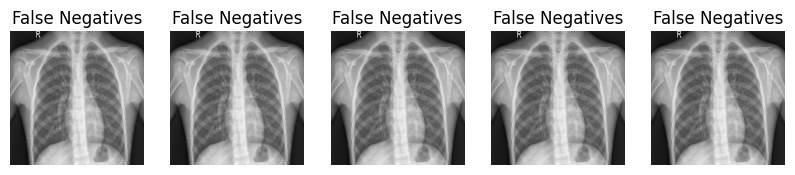

In [65]:
def show_samples(indices, title):
    plt.figure(figsize=(10,5))
    for i, idx in enumerate(indices[:5]):
        img, _ = test_gen[idx]
        plt.subplot(1,5,i+1)
        plt.imshow(img[0])
        plt.title(title)
        plt.axis('off')
    plt.show()

show_samples(fp_mob, "False Positives")
show_samples(fn_mob, "False Negatives")

# Grad CAM

In [75]:
def get_gradcam(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [77]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    img_array = img / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    return img, img_array

In [79]:
img_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg"

original_img, img_array = preprocess_image(img_path)

heatmap = get_gradcam(
    mobilenet_model,
    img_array,
    last_conv_layer_name="Conv_1"
)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_339']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [80]:
def overlay_gradcam(original_img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(original_img, 1-alpha, heatmap_color, alpha, 0)

    return overlay

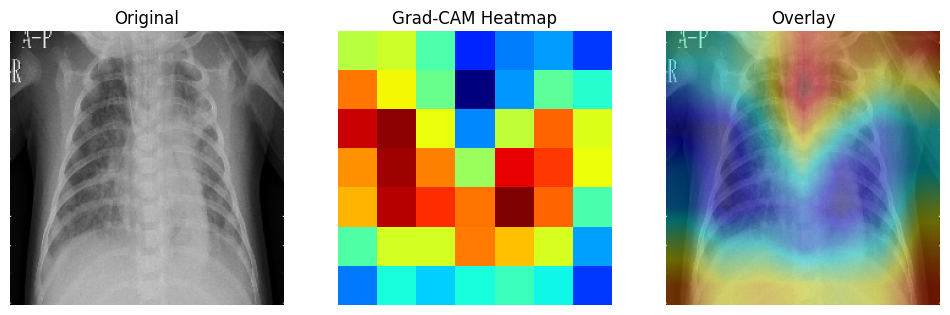

In [81]:
overlay = overlay_gradcam(original_img, heatmap)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(original_img)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Grad-CAM Heatmap")
plt.imshow(heatmap, cmap='jet')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis('off')

plt.show()

In [82]:
pred = mobilenet_model.predict(img_array)[0][0]

label = "PNEUMONIA" if pred > 0.5 else "NORMAL"
confidence = pred if pred > 0.5 else 1 - pred

print(f"Prediction: {label} ({confidence:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Prediction: PNEUMONIA (1.00)


# Save Models

## Save FULL MODELS

In [66]:
# save mobilenet model
mobilenet_model.save("mobilenet_pneumonia.keras")

# save resnet model
resnet_model.save("resnet50_pneumonia.keras")

## Save WEIGHTS ONLY

In [68]:
# mobilenet_model.save_weights("mobilenet_weights.h5")
# resnet_model.save_weights("resnet_weights.h5")

# Updated for Keras 3 compatibility
mobilenet_model.save_weights("mobilenet_weights.weights.h5")
resnet_model.save_weights("resnet_weights.weights.h5")

## Save TRAINING HISTORY

In [70]:
with open("mobilenet_history.json", "w") as f:
    json.dump(history_mob.history, f)

with open("resnet_history.json", "w") as f:
    json.dump(history_res.history, f)

## Save EVALUATION RESULTS

In [72]:
df_results.to_csv("model_results.csv", index=True)

## Save Predictions

In [73]:
np.save("y_true.npy", y_true)

np.save("y_pred_mob.npy", y_pred_mob)
np.save("y_pred_prob_mob.npy", y_pred_prob_mob)

np.save("y_pred_res.npy", y_pred_res)
np.save("y_pred_prob_res.npy", y_pred_prob_res)

## Save Confusion Matrix Figures

In [74]:
plt.savefig("confusion_matrix_mobilenet.png")
plt.savefig("confusion_matrix_resnet.png")

<Figure size 640x480 with 0 Axes>

## Load Models Later

In [ ]:
mobilenet_model = load_model("mobilenet_pneumonia.keras")
resnet_model = load_model("resnet50_pneumonia.keras")